# Intel XE4 atoms — layouts

Every emulated **XE4 MMA and Copy atom**, with its `(thread, value)` layout printed and (for a few) drawn. Each atom mirrors a `Copy_Traits` / `MMA_Traits` specialization in the sycl-tla headers (`include/cute/{arch,atom}/*xe4*`).

In [1]:
%matplotlib inline
import matplotlib
from tensor_layouts import size, rank
from tensor_layouts.analysis import atom_summary, is_bijective
from tensor_layouts.viz import draw_mma_layout, draw_copy_atom, draw_layout
import tensor_layouts.atoms_xe4 as A
from tensor_layouts.atoms_xe_common import make_slm_layout_elem
print('MMA:', len(A.MMA_ATOMS_XE4), ' Copy:', len(A.COPY_ATOMS_XE4))

MMA: 20  Copy: 25


## MMA atoms

For each atom: shape, ThrID, and the A/B/C `(thread,value)` layouts.

In [2]:
for a in A.MMA_ATOMS_XE4:
    print(f'{a.name:56s} MNK={a.shape_mnk} ThrID={size(a.thr_id)}')
    print(f'    A={a.a_layout}')
    print(f'    B={a.b_layout}')
    print(f'    C={a.c_layout}')

XE4_TMM_32x32x16_F32BF16BF16F32                          MNK=(32, 32, 16) ThrID=32
    A=(32, 16) : (1, 32)
    B=(32, 16) : (1, 32)
    C=(32, 32) : (1, 32)
XE4_TMM_32x32x16_F32F16F16F32                            MNK=(32, 32, 16) ThrID=32
    A=(32, 16) : (1, 32)
    B=(32, 16) : (1, 32)
    C=(32, 32) : (1, 32)
XE4_TMM_32x32x8_F32TF32TF32F32                           MNK=(32, 32, 8) ThrID=32
    A=(32, 8) : (1, 32)
    B=(32, 8) : (1, 32)
    C=(32, 32) : (1, 32)
XE4_TMM_32x32x32_S32S8S8S32                              MNK=(32, 32, 32) ThrID=32
    A=(32, 32) : (1, 32)
    B=(32, 32) : (1, 32)
    C=(32, 32) : (1, 32)
XE4_TMM_32x32x32_F32E4M3E4M3F32                          MNK=(32, 32, 32) ThrID=32
    A=(32, 32) : (1, 32)
    B=(32, 32) : (1, 32)
    C=(32, 32) : (1, 32)
XE4_AMMA_128x128x32_F32BF16BF16F32                       MNK=(128, 128, 32) ThrID=1
    A=(1, (128, 32)) : (0, (1, 128))
    B=(1, (128, 32)) : (0, (1, 128))
    C=(1, (128, 128)) : (0, (1, 128))
XE4_AMMA_GROUPSYN

### A drawn example — XE4_TMM register MMA

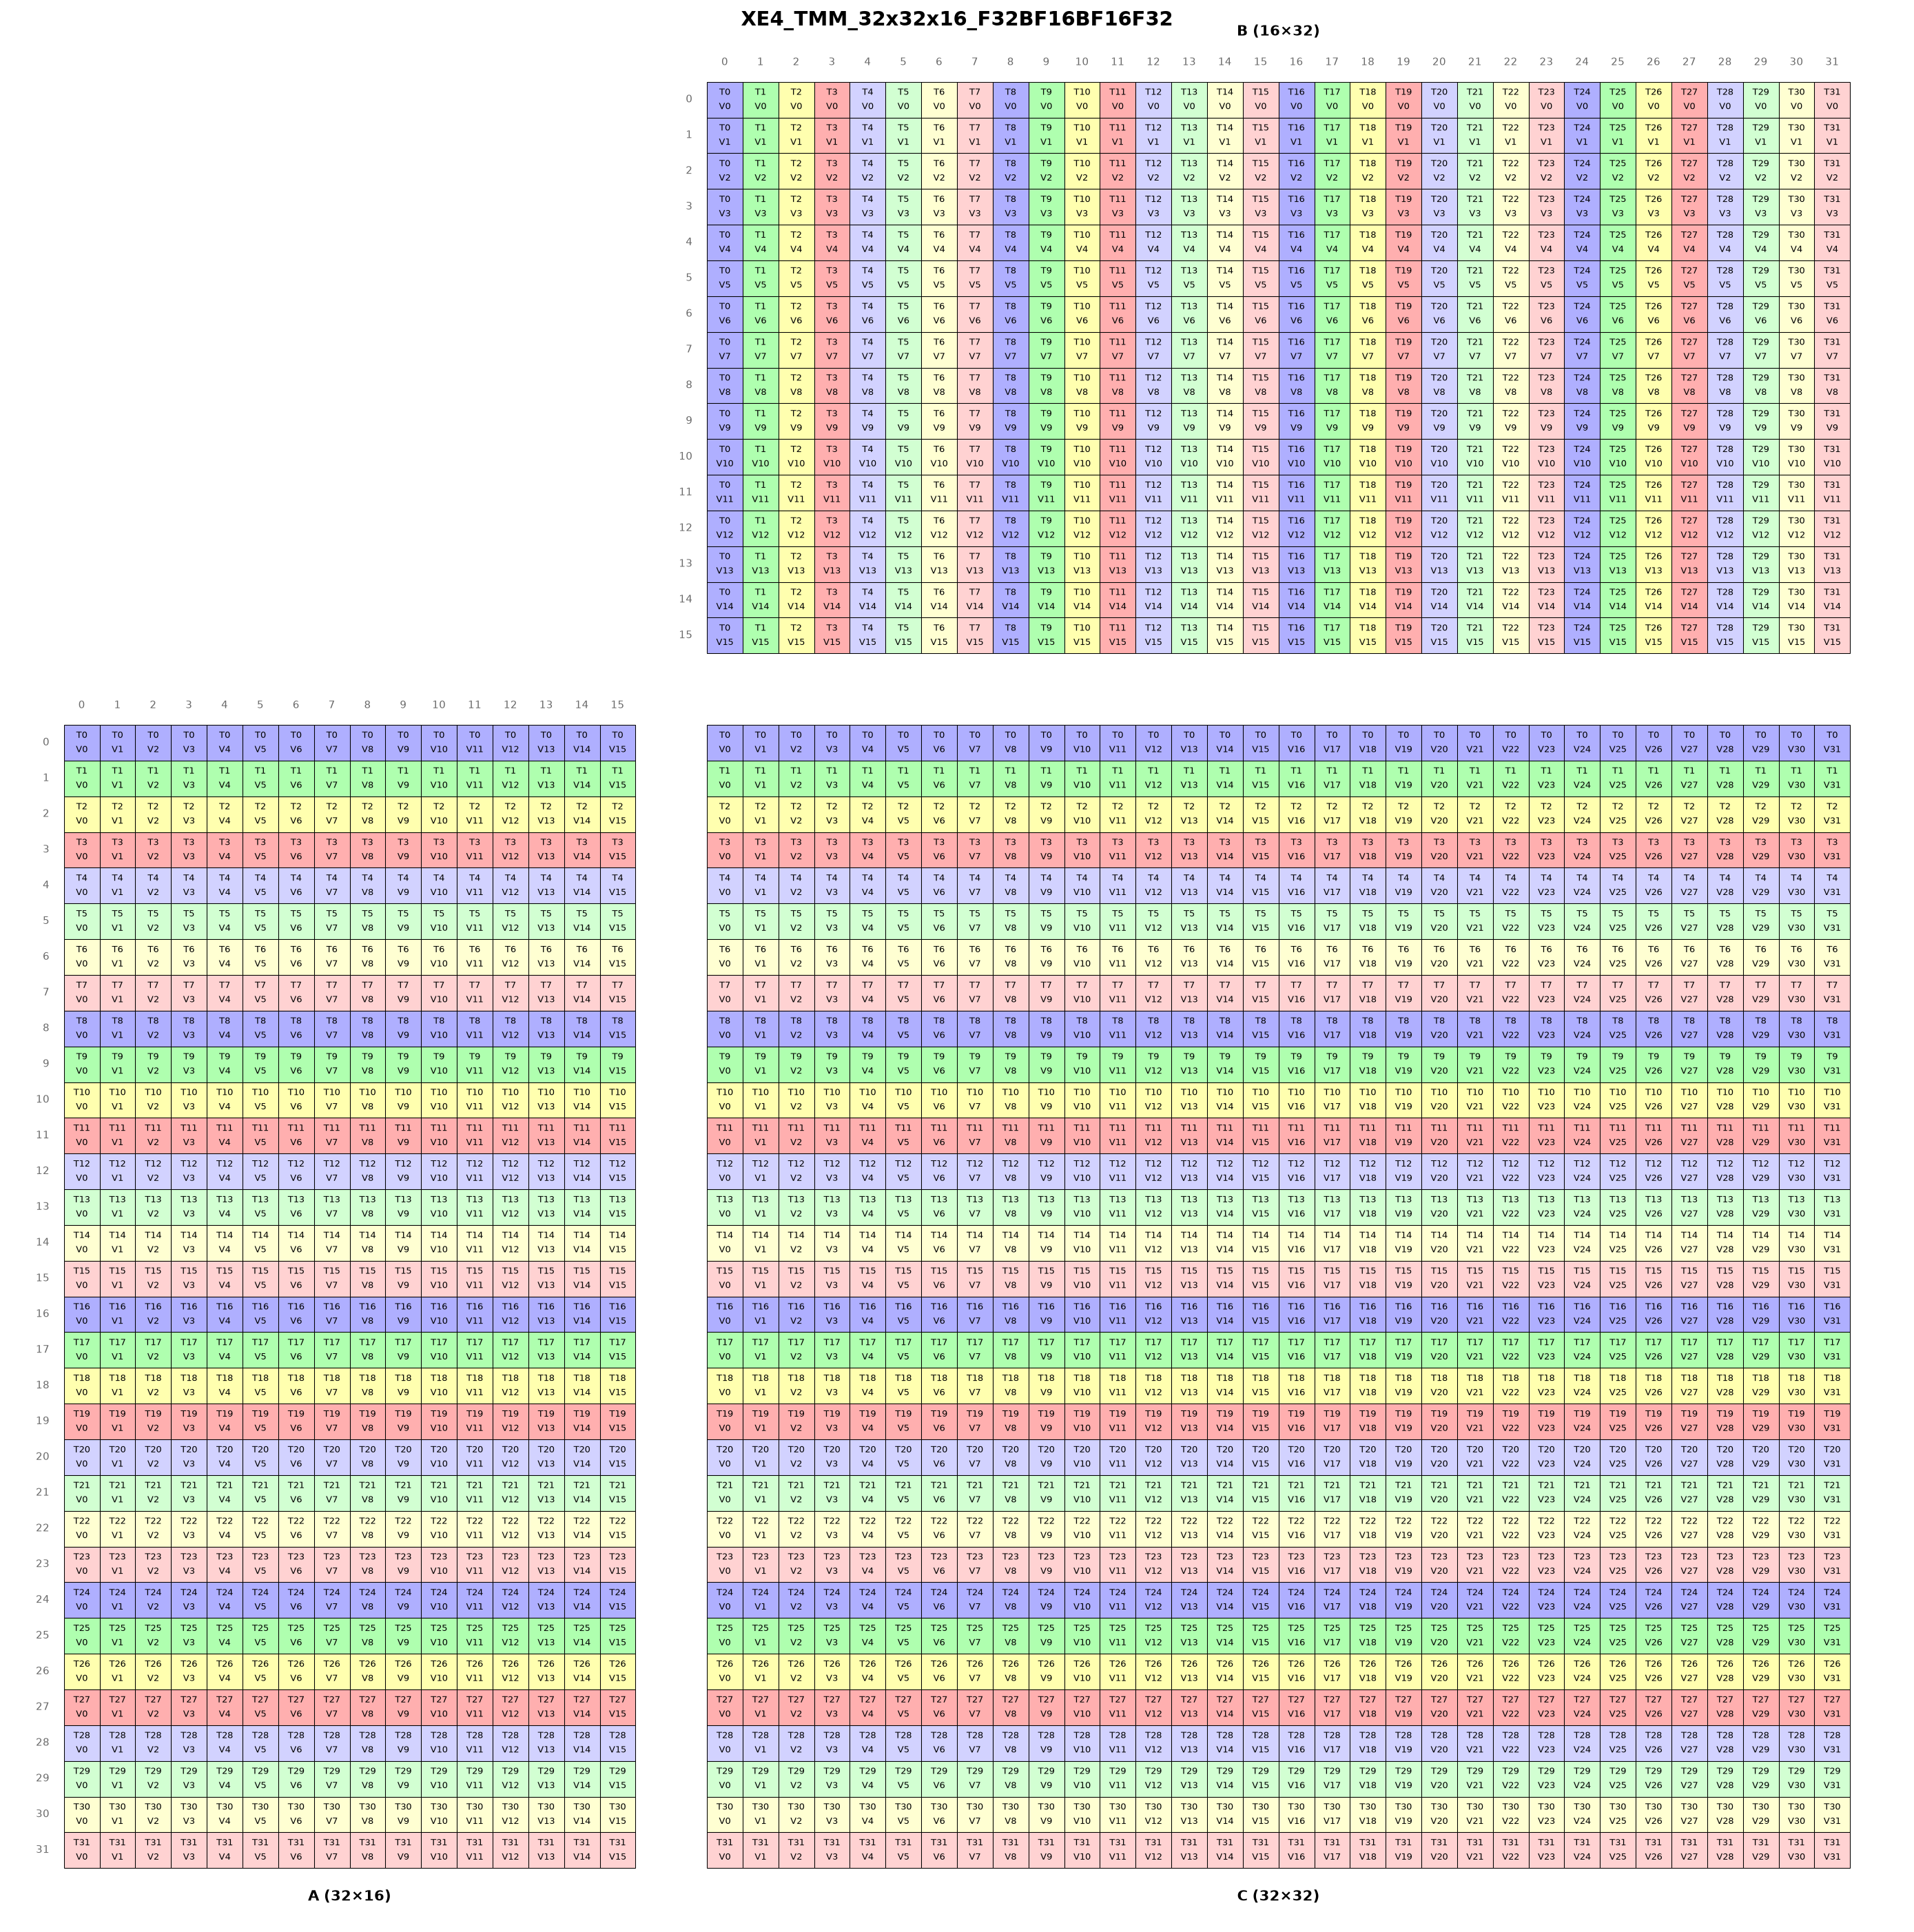

In [3]:
t = A.MMA_ATOMS_XE4_TMM[0]
draw_mma_layout(t.a_layout, t.b_layout, t.c_layout, tile_mnk=t.shape_mnk,
                main_title=t.name, thr_id_layout=t.thr_id)

### The AMMA physical SLM tile (32×32)

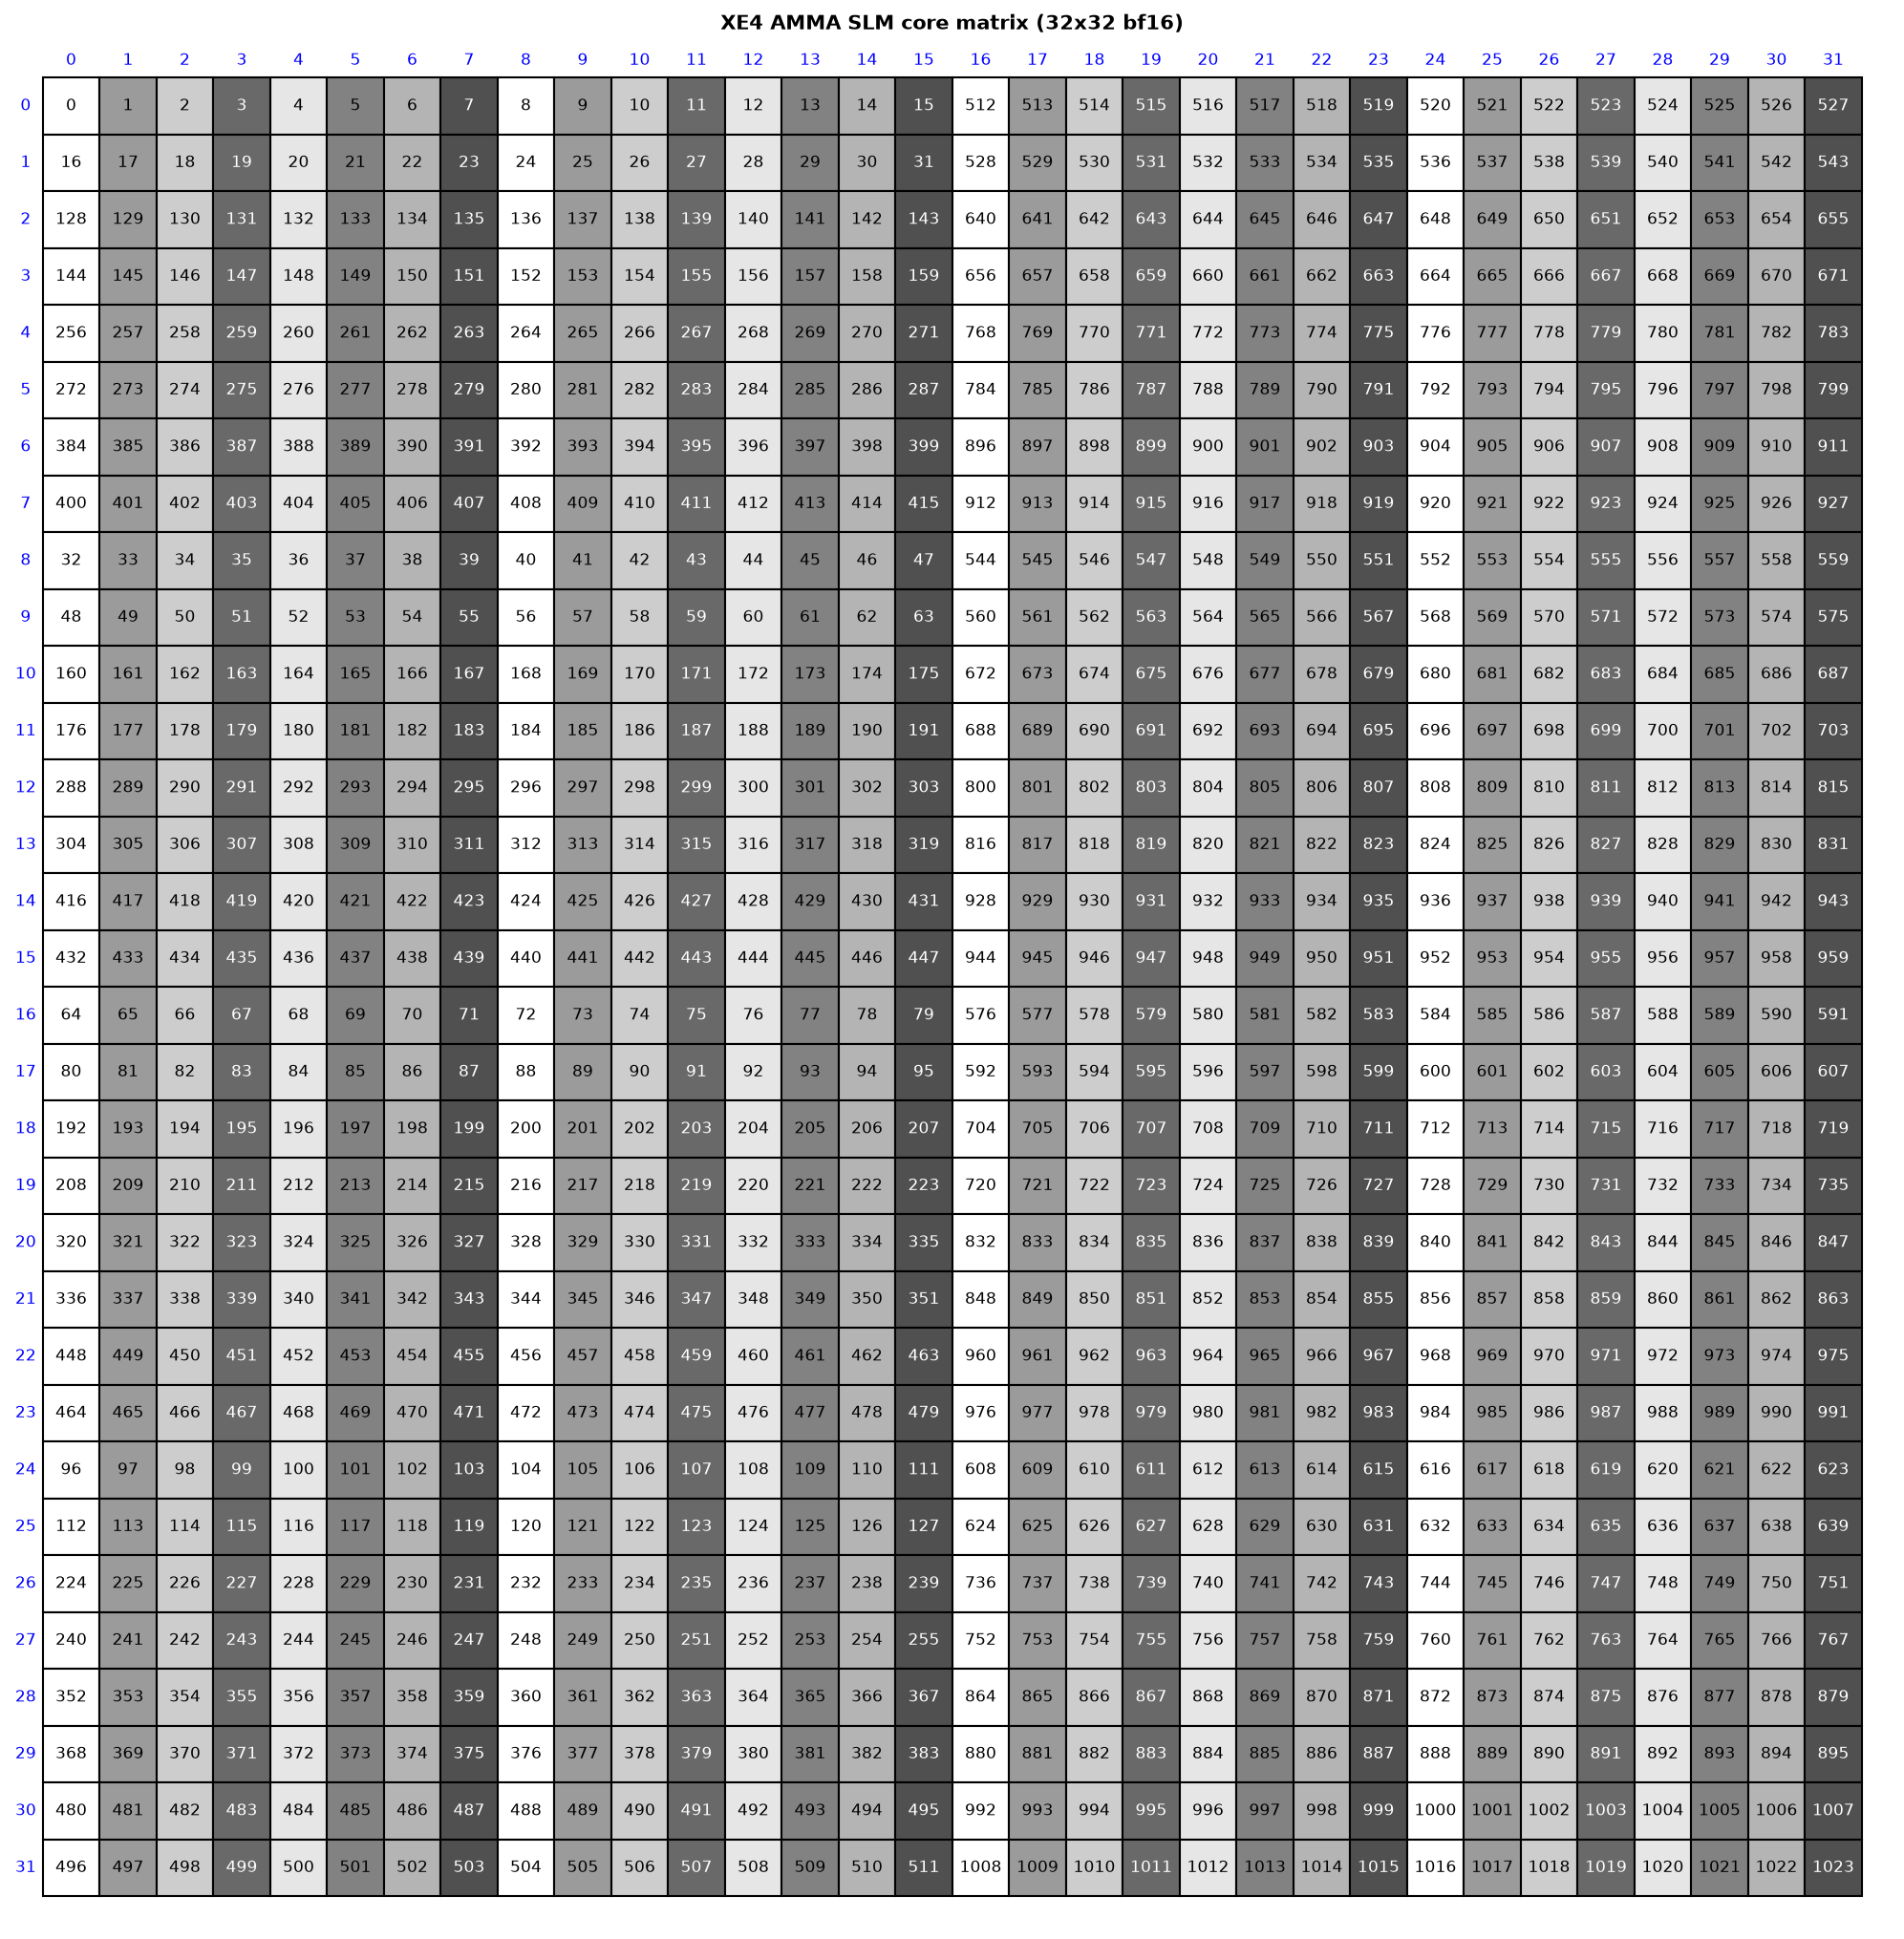

In [4]:
draw_layout(make_slm_layout_elem(16, 32, 32), title='XE4 AMMA SLM core matrix (32x32 bf16)')

## Copy atoms

`(thread, value) → bit` source and destination layouts.

In [5]:
for c in A.COPY_ATOMS_XE4:
    print(f'{c.name:46s} ThrID={size(c.thr_id):2d}  src={c.src_layout_bits}  dst={c.dst_layout_bits}')

XE4_ADMA_LINEAR_LOAD                           ThrID= 1  src=(1, 512) : (0, 1)  dst=(1, 512) : (0, 1)
XE4_ADMA_LINEAR_STORE                          ThrID= 1  src=(1, 512) : (0, 1)  dst=(1, 512) : (0, 1)
XE4_ADMA_LINEAR_LOAD_MULTICAST_CLUSTER         ThrID= 1  src=(1, 512) : (0, 1)  dst=(1, 512) : (0, 1)
XE4_ADMA_LINEAR_LOAD_LOCAL_TO_REMOTE_SLM_CLUSTER ThrID= 1  src=(1, 512) : (0, 1)  dst=(1, 512) : (0, 1)
XE4_ADMA_LINEAR_PREFETCH                       ThrID= 1  src=(1, 512) : (0, 1)  dst=(1, 512) : (0, 1)
XE4_ADMA_LINEAR_REDUCE                         ThrID= 1  src=(1, 512) : (0, 1)  dst=(1, 512) : (0, 1)
XE4_ADMA_ROW_COPY_LINEAR_LOAD                  ThrID= 1  src=(1, 256) : (0, 1)  dst=(1, 256) : (0, 1)
XE4_ADMA_ROW_COPY_LINEAR_LOAD_WARP             ThrID=32  src=(32, 256) : (256, 1)  dst=(32, 256) : (256, 1)
XE4_ADMA_ROW_COPY_LINEAR_STORE                 ThrID= 1  src=(1, 256) : (0, 1)  dst=(1, 256) : (0, 1)
XE4_ADMA_ROW_PREFETCH                          ThrID= 1  src=(1, 256) : (0

### A drawn copy — XE4_LDSM warp-row load

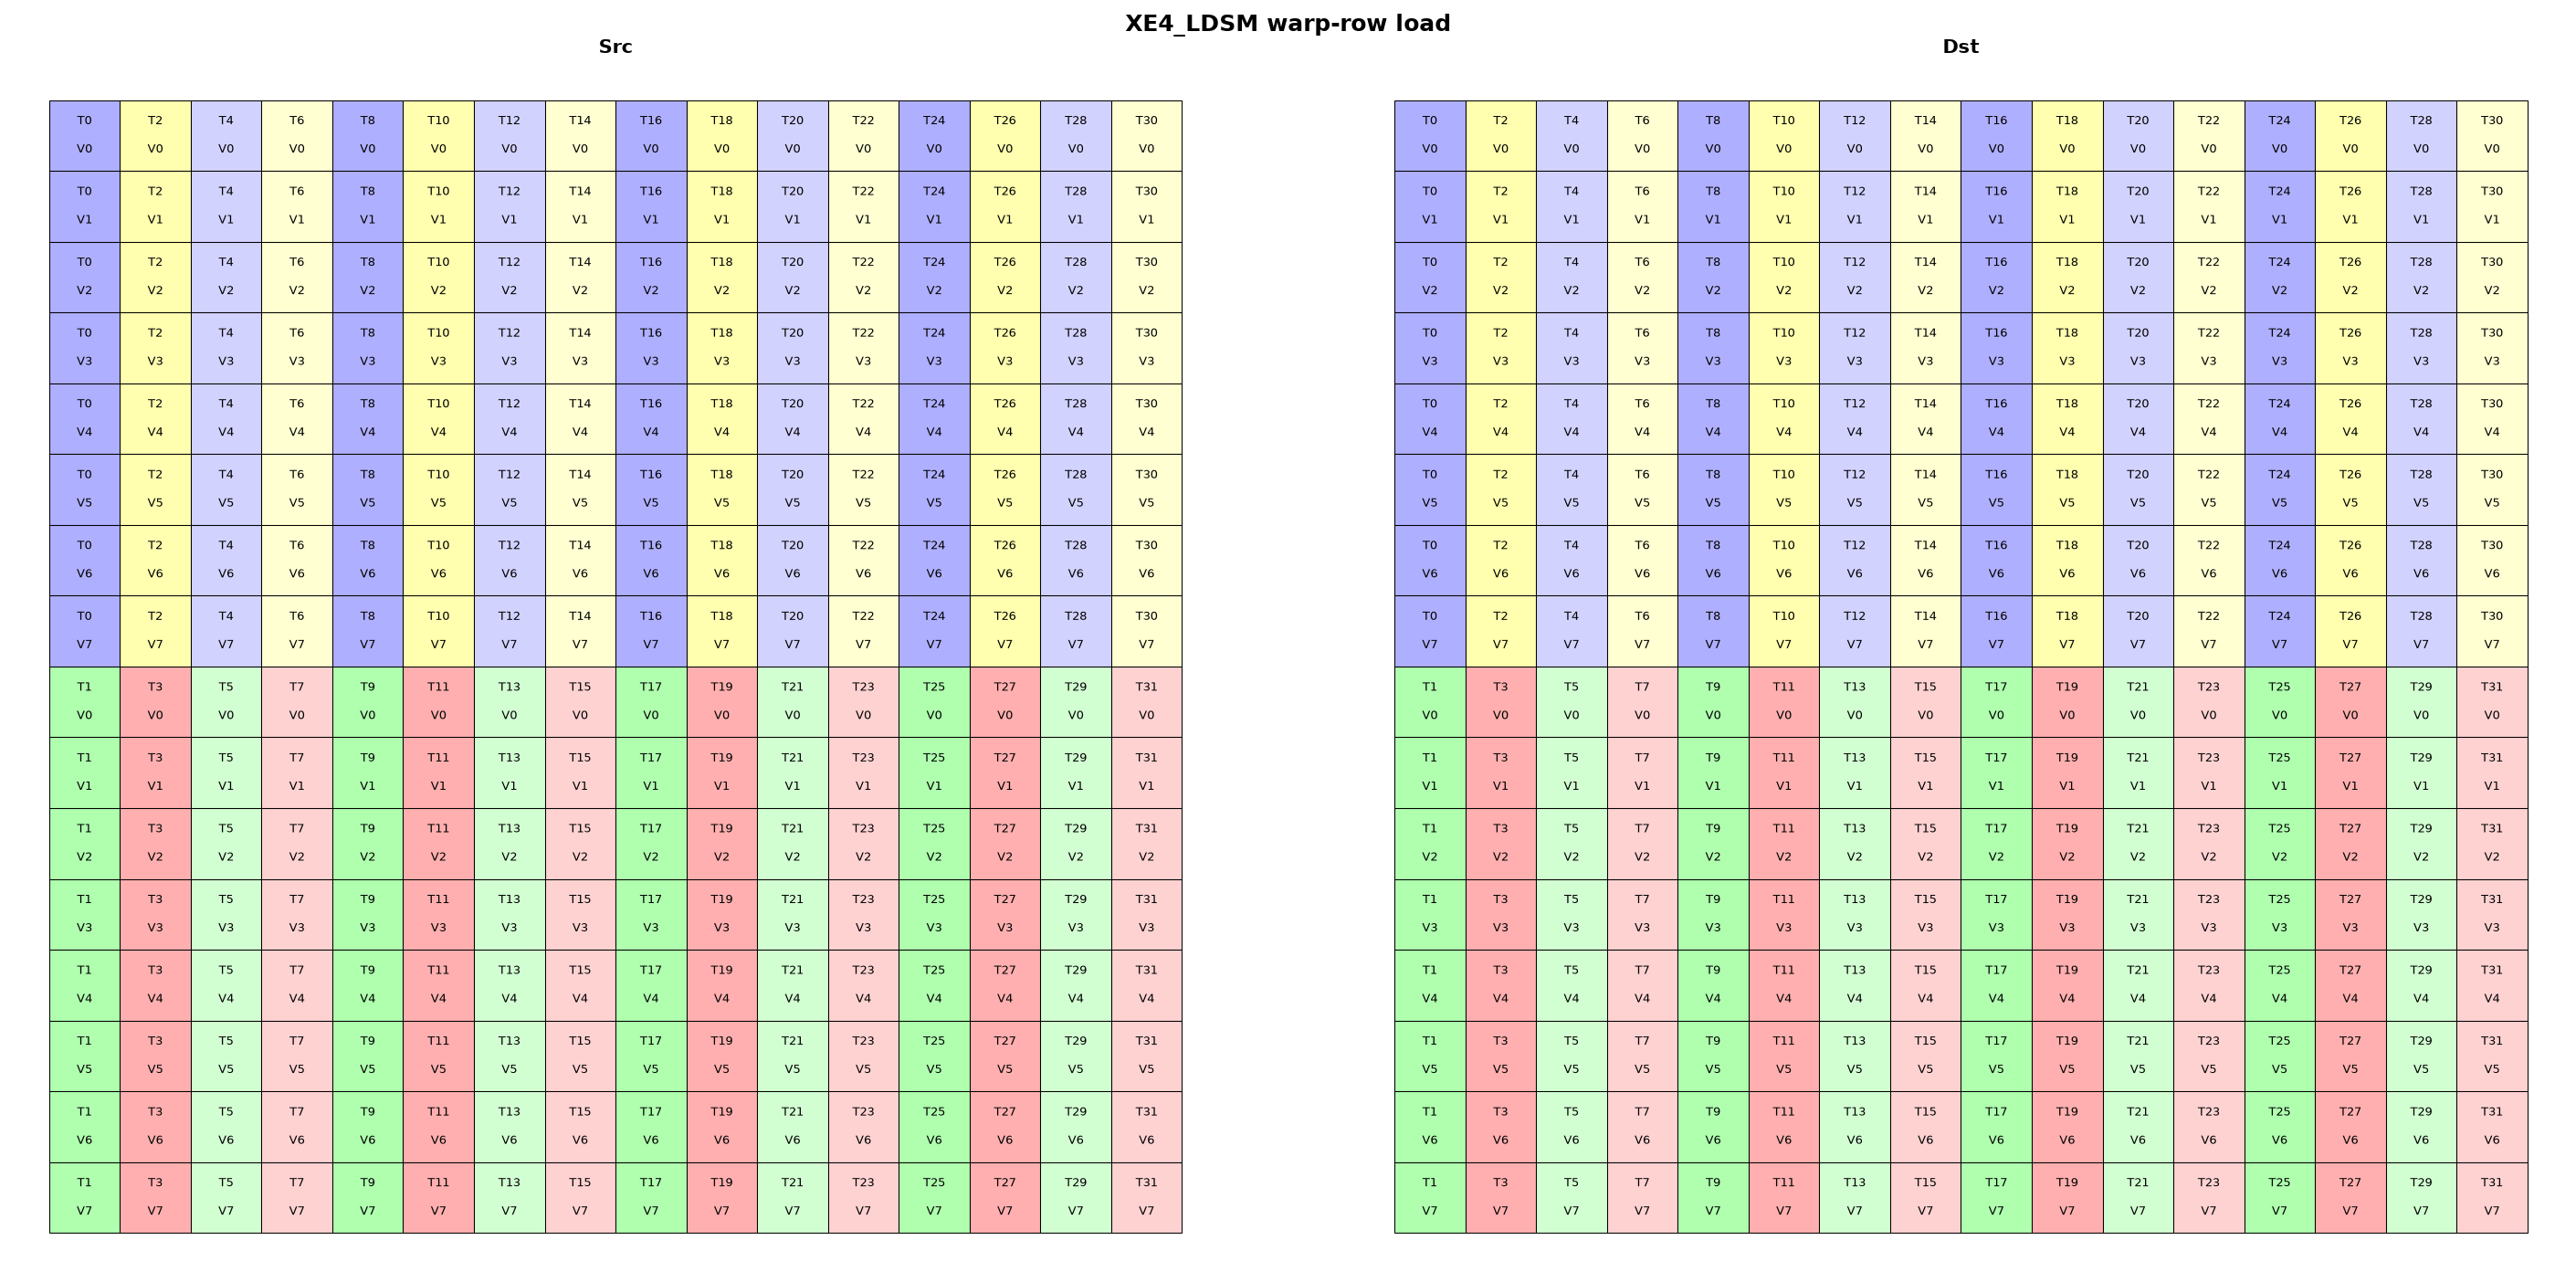

In [6]:
from tensor_layouts.atoms_xe4 import make_xe4_ldstm
draw_copy_atom(make_xe4_ldstm('LDSM', VS=8, s='bf16'), element_bits=16,
               title='XE4_LDSM warp-row load')